In [89]:
%load_ext autoreload
%autoreload 2

import os

import geopandas as gpd
import polars as pl
import polars_st as st
import pyogrio
import requests
from electoralyze import region
from electoralyze.common.constants import ROOT_DIR
from electoralyze.common.geometry import to_geopandas, to_geopolars
from electoralyze.common.parsing import clean_string

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: >

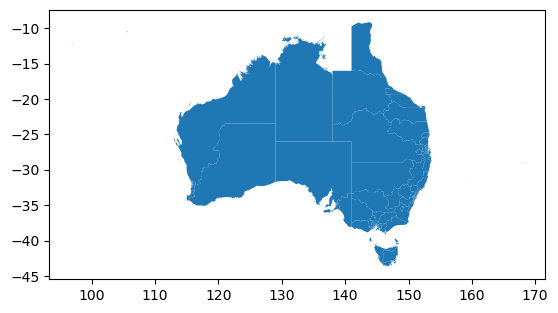

In [90]:
region.Federal2022.geometry.pipe(to_geopandas).plot()

In [91]:
results_per_polling_place_url = "https://results.aec.gov.au/27966/Website/External/HouseDopByPPDownload-27966-VIC.zip"
results_per_polling_place_url

'https://results.aec.gov.au/27966/Website/External/HouseDopByPPDownload-27966-VIC.zip'

In [92]:
force_new = False

In [93]:
from electoralyze.common.files import download_file

pp_results_file = (
    "/home/andre/git/private/electoralyze/experiments/05_electrion_data/01_federal_2022/" + "temp/results_by_pp.zip"
)
download_file(results_per_polling_place_url, pp_results_file, force_new=force_new)

In [94]:
os

<module 'os' (frozen)>

In [95]:
from zipfile import ZipFile

with ZipFile(pp_results_file, "r") as zip:
    zip.printdir()

File Name                                             Modified             Size
HouseDopByPPDownload-27966-VIC-ASTO.csv        2022-07-04 14:40:32      1072323
HouseDopByPPDownload-27966-VIC-BALL.csv        2022-07-04 14:40:34      2049826
HouseDopByPPDownload-27966-VIC-BEND.csv        2022-07-04 14:40:42      1622692
HouseDopByPPDownload-27966-VIC-BRUC.csv        2022-07-04 14:40:56       893930
HouseDopByPPDownload-27966-VIC-CALW.csv        2022-07-04 14:41:00       979197
HouseDopByPPDownload-27966-VIC-CASE.csv        2022-07-04 14:41:04      4387651
HouseDopByPPDownload-27966-VIC-CHIS.csv        2022-07-04 14:41:08      4520857
HouseDopByPPDownload-27966-VIC-COOP.csv        2022-07-04 14:41:10      1810022
HouseDopByPPDownload-27966-VIC-CORA.csv        2022-07-04 14:41:12      2060157
HouseDopByPPDownload-27966-VIC-CORI.csv        2022-07-04 14:41:12      1795906
HouseDopByPPDownload-27966-VIC-DEAK.csv        2022-07-04 14:41:20      2991421
HouseDopByPPDownload-27966-VIC-DUNK.csv 

In [96]:
# ZipFile(pp_results_file).extractall()

In [97]:
sample_data = pl.read_csv(ZipFile(pp_results_file).open("HouseDopByPPDownload-27966-VIC-MARI.csv"), skip_rows=1)
sample_data

StateAb,DivisionId,DivisionNm,PPId,PPNm,CountNum,BallotPosition,CandidateId,Surname,GivenNm,PartyAb,PartyNm,SittingMemberFl,CalculationType,CalculationValue
str,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,f64
"""VIC""",225,"""Maribyrnong""",0,"""ABSENT""",0,1,37196,"""HOBART""","""Mark Michael""","""GAP""","""The Great Australian Party""","""N""","""Preference Count""",83.0
"""VIC""",225,"""Maribyrnong""",0,"""ABSENT""",0,1,37196,"""HOBART""","""Mark Michael""","""GAP""","""The Great Australian Party""","""N""","""Preference Percent""",2.67
"""VIC""",225,"""Maribyrnong""",0,"""ABSENT""",0,1,37196,"""HOBART""","""Mark Michael""","""GAP""","""The Great Australian Party""","""N""","""Transfer Count""",0.0
"""VIC""",225,"""Maribyrnong""",0,"""ABSENT""",0,1,37196,"""HOBART""","""Mark Michael""","""GAP""","""The Great Australian Party""","""N""","""Transfer Percent""",0.0
"""VIC""",225,"""Maribyrnong""",0,"""ABSENT""",0,2,36660,"""DADICH""","""Daniel Nair""","""VNS""","""Victorian Socialists""","""N""","""Preference Count""",86.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""VIC""",225,"""Maribyrnong""",108544,"""EAV COVID19 Maribyrnong PPVC""",7,8,37582,"""ANSALONE""","""Alexander Anthony""","""CYA""","""Australian Federation Party""","""N""","""Transfer Percent""",0.0
"""VIC""",225,"""Maribyrnong""",108544,"""EAV COVID19 Maribyrnong PPVC""",7,9,36954,"""SMITH""","""Cameron James""","""LDP""","""Liberal Democratic Party""","""N""","""Preference Count""",0.0
"""VIC""",225,"""Maribyrnong""",108544,"""EAV COVID19 Maribyrnong PPVC""",7,9,36954,"""SMITH""","""Cameron James""","""LDP""","""Liberal Democratic Party""","""N""","""Preference Percent""",0.0


In [98]:
sample_data.schema

Schema([('StateAb', String),
        ('DivisionId', Int64),
        ('DivisionNm', String),
        ('PPId', Int64),
        ('PPNm', String),
        ('CountNum', Int64),
        ('BallotPosition', Int64),
        ('CandidateId', Int64),
        ('Surname', String),
        ('GivenNm', String),
        ('PartyAb', String),
        ('PartyNm', String),
        ('SittingMemberFl', String),
        ('CalculationType', String),
        ('CalculationValue', Float64)])

In [99]:
schema = pl.Schema(
    [
        ("StateAb", pl.String),
        ("DivisionId", pl.Int64),
        ("DivisionNm", pl.String),
        ("PPId", pl.Int64),
        ("PPNm", pl.String),
        ("CountNum", pl.Int64),
        ("BallotPosition", pl.Int64),
        ("CandidateId", pl.Int64),
        ("Surname", pl.String),
        ("GivenNm", pl.String),
        ("PartyAb", pl.String),
        ("PartyNm", pl.String),
        ("SittingMemberFl", pl.String),
        ("CalculationType", pl.String),
        ("CalculationValue", pl.Float64),
    ]
)

In [100]:
from electoralyze.common.files import pl_scan_csv_zip

election_data = pl_scan_csv_zip(csv_zip_url=pp_results_file, schema=schema, add_file_name=False, skip_rows=1)

In [101]:
election_data.tail(5).collect()

StateAb,DivisionId,DivisionNm,PPId,PPNm,CountNum,BallotPosition,CandidateId,Surname,GivenNm,PartyAb,PartyNm,SittingMemberFl,CalculationType,CalculationValue
str,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,f64
"""VIC""",234,"""Wills""",108546,"""EAV COVID19 Wills PPVC""",7,8,36686,"""HORSFALL""","""Leah Kim""","""AJP""","""Animal Justice Party""","""N""","""Transfer Percent""",0.0
"""VIC""",234,"""Wills""",108546,"""EAV COVID19 Wills PPVC""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Count""",235.0
"""VIC""",234,"""Wills""",108546,"""EAV COVID19 Wills PPVC""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Percent""",44.01
"""VIC""",234,"""Wills""",108546,"""EAV COVID19 Wills PPVC""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Transfer Count""",25.0
"""VIC""",234,"""Wills""",108546,"""EAV COVID19 Wills PPVC""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Transfer Percent""",29.41


In [102]:
pp_to_sa1_url = (
    "https://www.aec.gov.au/Elections/federal_elections/2022/files/downloads/2022-federal-election-votes-sa1.csv"
)
pp_to_sa1_file = (
    "/home/andre/git/private/electoralyze/experiments/05_electrion_data/01_federal_2022/" + "temp/pp_to_sa1.csv"
)
download_file(pp_to_sa1_url, pp_to_sa1_file, force_new=force_new)

In [103]:
pp_to_sa1 = pl.scan_csv(pp_to_sa1_file)
pp_to_sa1.head(10).collect()

year,state_ab,div_nm,ccd_id,pp_id,pp_nm,votes
i64,str,str,i64,i64,str,i64
2022,"""SA""","""Adelaide""",4100101,0,"""Absent""",22
2022,"""SA""","""Adelaide""",4100101,6648,"""Adelaide (Adelaide)""",3
2022,"""SA""","""Adelaide""",4100101,32952,"""Adelaide ADELAIDE PPVC""",53
2022,"""SA""","""Adelaide""",4100101,6649,"""Adelaide East""",45
2022,"""SA""","""Adelaide""",4100101,6651,"""Adelaide South""",99
2022,"""SA""","""Adelaide""",4100101,83454,"""Adelaide West""",7
2022,"""SA""","""Adelaide""",4100101,6655,"""Broadview""",1
2022,"""SA""","""Adelaide""",4100101,83760,"""Colonel Light Gardens ADELAIDE…",11
2022,"""SA""","""Adelaide""",4100101,108580,"""EAV COVID19 Adelaide PPVC""",3


# Federal aggregated

In [132]:
election_data.head().collect()

StateAb,DivisionId,DivisionNm,PPId,PPNm,CountNum,BallotPosition,CandidateId,Surname,GivenNm,PartyAb,PartyNm,SittingMemberFl,CalculationType,CalculationValue
str,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,f64
"""VIC""",197,"""Aston""",0,"""ABSENT""",0,1,35983,"""SPELMAN""","""Rebekah Jane""","""UAPP""","""United Australia Party""","""N""","""Preference Count""",291.0
"""VIC""",197,"""Aston""",0,"""ABSENT""",0,1,35983,"""SPELMAN""","""Rebekah Jane""","""UAPP""","""United Australia Party""","""N""","""Preference Percent""",10.29
"""VIC""",197,"""Aston""",0,"""ABSENT""",0,1,35983,"""SPELMAN""","""Rebekah Jane""","""UAPP""","""United Australia Party""","""N""","""Transfer Count""",0.0
"""VIC""",197,"""Aston""",0,"""ABSENT""",0,1,35983,"""SPELMAN""","""Rebekah Jane""","""UAPP""","""United Australia Party""","""N""","""Transfer Percent""",0.0
"""VIC""",197,"""Aston""",0,"""ABSENT""",0,2,36704,"""TUDGE""","""Alan Edward""","""LP""","""Liberal Party of Australia (Vi…","""Y""","""Preference Count""",870.0


In [157]:
# election_data.select('DivisionNm').unique().collect()
election_data.select("PartyNm").unique().collect().sample(10)

PartyNm
str
"""Pauline Hanson's One Nation"""
"""Animal Justice Party"""
"""The Great Australian Party"""
"""FUSION: Science, Pirate, Secul…"
"""The Australian Greens - Victor…"
"""United Australia Party"""
"""Reason Australia"""
"""Australian Values Party"""
"""National Party of Australia - …"


In [136]:
election_data.head().collect()
(
    election_data.filter(
        pl.col("CalculationType") == "Preference Count",
        pl.col("CountNum").eq(pl.col("CountNum").max()).over("DivisionNm"),
        pl.col("CalculationValue") != 0,
    )
    .group_by("DivisionNm", "CandidateId")
    .agg(
        pl.col("CalculationValue").sum().alias("Votes"),
    )
    .collect()
)

DivisionNm,CandidateId,Votes
str,i64,f64
"""Scullin""",36447,59761.0
"""Corio""",36381,60919.0
"""Macnamara""",36736,35120.0
"""Jagajaga""",36726,38121.0
"""Isaacs""",36434,55818.0
…,…,…
"""Lalor""",36443,55613.0
"""Casey""",36379,48338.0
"""Gippsland""",36048,71205.0


In [163]:
election_data.head().collect()
data_per_electorate = (
    election_data.filter(
        pl.col("CalculationType") == "Preference Count",
        pl.col("CountNum") == 0,
        # pl.col('PartyAb') == 'GRN',
        # pl.col('CalculationValue') != 0,
        pl.col("PartyNm") == "The Australian Greens - Victoria",
    )
    .group_by("DivisionNm", "CandidateId")
    .agg(
        pl.col("CalculationValue").sum().alias("Votes"),
    )
    .select(clean_string("DivisionNm").alias(region.Federal2022.id), "Votes")
    .collect()
)
data_per_electorate

federal_2022,Votes
str,f64
"""deakin""",13904.0
"""ballarat""",14076.0
"""bendigo""",14026.0
"""wills""",25793.0
"""mallee""",5463.0
…,…
"""jagajaga""",16855.0
"""flinders""",9293.0
"""gorton""",8325.0


In [ ]:
election_data.head().collect()
(
    election_data.filter(
        pl.col("CalculationType") == "Preference Count",
        pl.col("CountNum").eq(pl.col("CountNum").max()).over("DivisionNm"),
        pl.col("CalculationValue") != 0,
    )
    .group_by("DivisionNm", "CandidateId")
    .agg(
        pl.col("CalculationValue").sum().alias("Votes"),
    )
    .collect()
)

In [105]:
region.Federal2022.geometry

federal_2022,geometry
str,binary
"""adelaide""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00W\x00\x00\x00u\x8e\x01\xd9kTa@\x82\xfd\xd7\xb9ioA\xc0\x00\x00\x00\x00\x00\x00\x00\x00\xd0\x98I\xd4\x0bTa@\x0a\xd68\x9b\x8epA\xc0\x00\x00\x00""…"
"""aston""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00\xd0\x02\x00\x00\xfc\x8e\xe1\xb1\x1f+b@|\xed\x99%\x01\xeeB\xc0\x00\x00\x00\x00\x00\x00\x00\x00;8\xd8\x9b\x18+b@-\xe8\xbd1\x04\xeeB\xc0\x00\x00\x00""…"
"""ballarat""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00D\x09\x00\x00J\xb2\x0eGW\xfaa@p\xb071$\x07C\xc0\x00\x00\x00\x00\x00\x00\x00\x00\x05\xc0x\x06\x8d\xfaa@\xfa\xd1p\xca\xdc\x02C\xc0\x00\x00\x00""…"
"""banks""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00\x9b\x00\x00\x00\xab\x07\xccC&\xe4b@\x96\xaf\xcb\xf0\x9f\xfc@\xc0\x00\x00\x00\x00\x00\x00\x00\x006#\x83\xdc\xc5\xe3b@\xfc\xdf\x11\x15\xaa\xfd@\xc0\x00\x00\x00""…"
"""barker""","b""\x01\x06\x00\x00\xa0\xe6\x10\x00\x00\x1b\x00\x00\x00\x01\x03\x00\x00\x80\x01\x00\x00\x00M\x0d\x00\x00wj.7\x18\xa0a@\xa3\x05h[\xcd\x02A\xc0\x00\x00\x00\x00\x00\x00\x00\x00\xa0PO\x1f\x01\xa0a@r7""…"
…,…
"""werriwa""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00\x1d\x01\x00\x00*\x8d\x98\xd9g\xddb@\xf7\xe67L4\xf8@\xc0\x00\x00\x00\x00\x00\x00\x00\x00\x1a\x17\x0e\x84d\xddb@G\xc8@\x9e]\xf8@\xc0\x00\x00\x00""…"
"""whitlam""","b""\x01\x06\x00\x00\xa0\xe6\x10\x00\x00\x02\x00\x00\x00\x01\x03\x00\x00\x80\x01\x00\x00\x00\xd9\x04\x00\x00y\x95\xb5M\xf1\xdcb@\x17a\x8ariLA\xc0\x00\x00\x00\x00\x00\x00\x00\x00\xaf\xb1KT\xef\xdcb@u\x1e""…"
"""wide_bay""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00d\x0e\x00\x00\x8b\xe1\xea\x00\x88+c@\x01L\x198\xa0\x019\xc0\x00\x00\x00\x00\x00\x00\x00\x00\xf7\xb1\x82\xdf\x86+c@6\x93o\xb6\xb9\x019\xc0\x00\x00\x00""…"


In [165]:
(
    region.Federal2022.geometry.join(
        data_per_electorate,
        on=region.Federal2022.id,
        how="inner",
    )
    .pipe(to_geopandas)
    .explore("Votes")
)

# Testings redistributing

In [106]:
final_will_count = 7
slice_2cp_by_pp = election_data.filter(
    pl.col("DivisionNm") == "Wills",
    pl.col("CountNum") == final_will_count,
    pl.col("CalculationType") == "Preference Count",
    pl.col("CalculationValue") != 0,
).collect()

ppid = 0

slice_2cp_by_pp["PPId"].unique()
slice_2cp_by_pp.filter(pl.col("PPId") == ppid)

StateAb,DivisionId,DivisionNm,PPId,PPNm,CountNum,BallotPosition,CandidateId,Surname,GivenNm,PartyAb,PartyNm,SittingMemberFl,CalculationType,CalculationValue
str,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,f64
"""VIC""",234,"""Wills""",0,"""ABSENT""",7,7,36452,"""KHALIL""","""Peter""","""ALP""","""Australian Labor Party (Victor…","""Y""","""Preference Count""",1885.0
"""VIC""",234,"""Wills""",0,"""ABSENT""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Count""",2140.0
"""VIC""",234,"""Wills""",0,"""POSTAL""",7,7,36452,"""KHALIL""","""Peter""","""ALP""","""Australian Labor Party (Victor…","""Y""","""Preference Count""",9430.0
"""VIC""",234,"""Wills""",0,"""POSTAL""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Count""",5598.0
"""VIC""",234,"""Wills""",0,"""PRE_POLL""",7,7,36452,"""KHALIL""","""Peter""","""ALP""","""Australian Labor Party (Victor…","""Y""","""Preference Count""",3270.0
"""VIC""",234,"""Wills""",0,"""PRE_POLL""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Count""",3014.0
"""VIC""",234,"""Wills""",0,"""PROVISIONAL""",7,7,36452,"""KHALIL""","""Peter""","""ALP""","""Australian Labor Party (Victor…","""Y""","""Preference Count""",171.0
"""VIC""",234,"""Wills""",0,"""PROVISIONAL""",7,9,36554,"""JEFFORD""","""Sarah Elizabeth""","""GVIC""","""The Australian Greens - Victor…","""N""","""Preference Count""",132.0


In [107]:
wills_2cp_by_pp = slice_2cp_by_pp.select(
    clean_string("PPNm").alias("poll_name"),
    pl.col("CandidateId").alias("candidate_id"),
    pl.col("CalculationValue").alias("votes"),
)
wills_2cp_by_pp

poll_name,candidate_id,votes
str,i64,f64
"""absent""",36452,1885.0
"""absent""",36554,2140.0
"""postal""",36452,9430.0
"""postal""",36554,5598.0
"""pre_poll""",36452,3270.0
…,…,…
"""melbourne_wills_ppvc""",36554,420.0
"""strathmore_north_(wills)""",36452,41.0
"""strathmore_north_(wills)""",36554,30.0


In [108]:
wills_pp_to_sa1 = (
    pp_to_sa1.filter(pl.col("div_nm") == "Wills")
    .collect()
    .select(
        clean_string("pp_nm").alias("poll_name"),
        pl.col("votes").alias("mapping"),
        pl.col("ccd_id").alias("ccd_id"),
    )
)
wills_pp_to_sa1

poll_name,mapping,ccd_id
str,i64,i64
"""absent""",6,2110501
"""brunswick_east_(wills)""",3,2110501
"""brunswick_north_east""",6,2110501
"""brunswick_south""",1,2110501
"""brunswick_south_east_(wills)""",1,2110501
…,…,…
"""pascoe_vale_north""",7,2144017
"""pascoe_vale_south""",1,2144017
"""pascoe_vale_wills_ppvc""",61,2144017


In [109]:
ccd_id = wills_pp_to_sa1["ccd_id"].sample(10).first()
filtered = region.SA1_2021.geometry.filter(
    pl.col(region.SA1_2021.id).cast(pl.String).str.ends_with(str(ccd_id)[1:]),
    pl.col(region.SA1_2021.id).cast(pl.String).str.starts_with(str(ccd_id)[0:1]),
)

print(ccd_id)
print(wills_pp_to_sa1.filter(pl.col("ccd_id") == ccd_id))
print(filtered)

filtered.pipe(to_geopandas).explore()

2143804
shape: (14, 3)
┌────────────────────────┬─────────┬─────────┐
│ poll_name              ┆ mapping ┆ ccd_id  │
│ ---                    ┆ ---     ┆ ---     │
│ str                    ┆ i64     ┆ i64     │
╞════════════════════════╪═════════╪═════════╡
│ absent                 ┆ 15      ┆ 2143804 │
│ essendon_wills_ppvc    ┆ 2       ┆ 2143804 │
│ glenroy                ┆ 6       ┆ 2143804 │
│ glenroy_east           ┆ 1       ┆ 2143804 │
│ glenroy_north          ┆ 3       ┆ 2143804 │
│ …                      ┆ …       ┆ …       │
│ pascoe_vale            ┆ 2       ┆ 2143804 │
│ pascoe_vale_wills_ppvc ┆ 96      ┆ 2143804 │
│ postal                 ┆ 54      ┆ 2143804 │
│ pre_poll               ┆ 24      ┆ 2143804 │
│ provisional            ┆ 1       ┆ 2143804 │
└────────────────────────┴─────────┴─────────┘
shape: (0, 2)
┌──────────┬──────────┐
│ SA1_2021 ┆ geometry │
│ ---      ┆ ---      │
│ i64      ┆ binary   │
╞══════════╪══════════╡
└──────────┴──────────┘


/tmp/ipykernel_21050/887098508.py:11: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  filtered.pipe(to_geopandas).explore()


In [110]:
wills_pp_to_sa1
wills_2cp_by_pp

poll_name,candidate_id,votes
str,i64,f64
"""absent""",36452,1885.0
"""absent""",36554,2140.0
"""postal""",36452,9430.0
"""postal""",36554,5598.0
"""pre_poll""",36452,3270.0
…,…,…
"""melbourne_wills_ppvc""",36554,420.0
"""strathmore_north_(wills)""",36452,41.0
"""strathmore_north_(wills)""",36554,30.0


In [111]:
from electoralyze.region.redistribute import redistribute


class PollNameRegion:
    id = "poll_name"


class CCDRegion:
    id = "ccd_id"


wills_2cp_by_ccd = redistribute(
    data_by_from=wills_2cp_by_pp,
    mapping=wills_pp_to_sa1,
    region_from=PollNameRegion,
    region_to=CCDRegion,
    index_columns=["candidate_id"],
)
wills_2cp_by_ccd

ccd_id,candidate_id,votes
i64,i64,f64
2123925,36452,255.020181
2110540,36452,188.75348
2110529,36554,156.897618
2110846,36554,118.826562
2110907,36554,108.61358
…,…,…
2110856,36452,73.107603
2144004,36554,48.141153
2143848,36554,79.507067


In [112]:
ccd_geoms = region.SA1_2021.geometry.with_columns(
    pl.concat_str(
        pl.col(region.SA1_2021.id).cast(pl.String).str.slice(0, 1),
        pl.col(region.SA1_2021.id).cast(pl.String).str.slice(5, 6),
    ).alias("ccd_id")
)
ccd_geoms.sample(3)

SA1_2021,geometry,ccd_id
i64,binary,str
30102100712,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xbc\x83\xc9(&(c@7Co\xa1$\x8a;\xc0\x1f\x9e\x98A((c@\x00ko\x91!\x89;\xc0\x11I\x8d\xc6L(c@\xb3\xd9\x9c""…","""3100712"""
10202105702,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\x15\x00\x00\x00\xc7\xe2\x0c\x96\xa3\xedb@\xd7A\x08\xa4p\xa1@\xc0\x93\xab\xc9\x8d\xa3\xedb@vF\xabGW\xa1@\xc0Gw'4\xa5\xedb@\x8c<\x7f""…","""1105702"""
21305146618,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\x08\x00\x00\x00\xcc\xed\xc0'\x80\x17b@""\xb9\xc0s\x8f\xf4B\xc0L\x8cp\xf5\x85\x17b@\x85\x7fVg\x0f\xf4B\xc0\xe8\xb8\xb8T\x98\x17b@p\xba\xcb""…","""2146618"""


In [113]:
wills_green_candidate_id = 36554
wills_labor_candidate_id = 36452

one_candidate_share = (
    wills_2cp_by_ccd.with_columns(pl.col("votes").truediv(pl.col("votes").sum()).over("ccd_id").alias("share"))
    .filter(pl.col("candidate_id") == wills_green_candidate_id)
    .select(
        pl.col("ccd_id").cast(pl.String),
        pl.col("share"),
    )
)
one_candidate_share

ccd_id,share
str,f64
"""2110529""",0.479514
"""2110846""",0.39737
"""2110907""",0.366563
"""2110728""",0.457762
"""2110613""",0.527253
…,…
"""2123944""",0.347465
"""2144004""",0.351805
"""2143848""",0.333288


In [114]:
wills_geom = region.Federal2022.geometry.filter(pl.col(region.Federal2022.id) == "wills")
wills_geom

federal_2022,geometry
str,binary
"""wills""","b""\x01\x03\x00\x00\xa0\xe6\x10\x00\x00\x01\x00\x00\x00D\x01\x00\x00\x16\x16\xdc\x0fx\x1fb@\xce\xe2\xc5\xc2\x10\xe3B\xc0\x00\x00\x00\x00\x00\x00\x00\x00\x0c\x02+\x87\x16\x1fb@\x84\xf2>\x8e\xe6\xe2B\xc0\x00\x00\x00""…"


In [115]:
(
    ccd_geoms.filter(st.geom("geometry").st.intersects(wills_geom["geometry"]))
    .join(
        one_candidate_share,
        on="ccd_id",
        how="inner",
    )
    # .filter(st.geom('geometry').st.within(wills_geom['geometry']))
    .pipe(to_geopandas)
    .explore("share")
)

In [116]:
one_candidate_share

ccd_id,share
str,f64
"""2110529""",0.479514
"""2110846""",0.39737
"""2110907""",0.366563
"""2110728""",0.457762
"""2110613""",0.527253
…,…
"""2123944""",0.347465
"""2144004""",0.351805
"""2143848""",0.333288


In [117]:
ccd_geoms

SA1_2021,geometry,ccd_id
i64,binary,str
10102100701,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\xc9\x02\x00\x00]\x16V\xf6\x80\xbcb@`j""\xe5\x88\x8bA\xc0K\x07\x81\xbe\x89\xbcb@\x98\xe7[Du\x8bA\xc0\xdc\x8d\x1c;\x92\xbcb@\xa9X\x94""…","""1100701"""
10102100702,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x02\x00\x00\x00\x08\x01\x00\x00Y\xdc\xe9\xa6~\xb7b@\x9e\xfb\xe0\x81\x0c\xafA\xc0\xb5Q\xabKL\xb8b@y\x87\xa0!}\xafA\xc0\xdc\xeb1\x0bW\xb8b@A\xb6\x8d""…","""1100702"""
10102100703,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\x1a\x00\x00\x00\x0f\xf0N\x9b\xf5\xb8b@\xd60\xf1\x91g\xb8A\xc0u\xc3C\xa7\xf2\xb8b@G8\xcb\xb4+\xb8A\xc0B6\xc1\xac\xfb\xb8b@^p\xe5""…","""1100703"""
10102100704,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00\x1e\x00\x00\x00\x95\x92\x10<}\xb9b@7J\xbb\x9f\x09\xb9A\xc0\xca1\xac\xee\x89\xb9b@j\x94\xfc\x020\xb8A\xc0RI\xbet\x8b\xb9b@\xc1\xe3\xb4""…","""1100704"""
10102100705,"b""\x01\x03\x00\x00\x20\xe6\x10\x00\x00\x01\x00\x00\x00""\x00\x00\x00\xdc\xbc\x02\x88p\xb9b@\xfe\x05l#y\xb9A\xc0g\x10R\x1cr\xb9b@X.\x07\x8cy\xb9A\xc0\x93\xecfnt\xb9b@Pc\x1f""…","""1100705"""
…,…,…
90104100406,"b""\x01\x06\x00\x00\x20\xe6\x10\x00\x00\x07\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x09\x00\x00\x00^\xa0\xef\xd6\xa7\xfed@\xc6\x1c\xf6c\x14\x01=\xc0H+\x9d\xbf\xa9\xfed@\xb5P\x14|T\x01=\xc0\x08X""…","""9100406"""
90104100407,"b""\x01\x06\x00\x00\x20\xe6\x10\x00\x00\x09\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\x88\x8d\x9c\xebT\xfdd@\x06\xf8)\xe8t\x02=\xc0\xb7:\x13\xc7Z\xfdd@z\xce\x1d\xf6m\x02=\xc0\x13T""…","""9100407"""
90104100408,"b""\x01\x06\x00\x00\x20\xe6\x10\x00\x00\x06\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00>\x00\x00\x00\x8d\x8b\xd7\x9b\xd4\xfed@\x95\xcf\x8e\x96\x83\x12=\xc0L\xe0\xf2\xc1\xd2\xfed@\xe1\x95\xdf\xaak\x12=\xc0\x89\xcc""…","""9100408"""
